In [ ]:
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense,Conv2D,MaxPooling2D, GRU
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import io
import scipy.ndimage

In [ ]:
upload =files.upload()
stock_data = pd.read_csv(io.BytesIO(upload['close price.csv']))
stock_data.head()

Saving close price.csv to close price.csv


,Date,Akhaber,Asia,Foulad,Hkashti,Mafakher,Nori,Satran,Shasta,Tejarat
0,20231231,11830,2136,6230,12480,12150,149510,8560,1265,2395
1,20231230,11830,2114,6280,12660,12710,149620,8610,1268,2421
2,20231227,11830,2076,6220,12590,13010,150250,8600,1264,2415
3,20231226,11880,2072,6210,12540,13260,149330,9030,1262,2428
4,20231225,11800,2068,6270,12830,13180,149770,9420,1273,2470


In [ ]:
stock_data = stock_data.sort_values(by='Date', ascending= True)
stock_data.head()

,Date,Akhaber,Asia,Foulad,Hkashti,Mafakher,Nori,Satran,Shasta,Tejarat
882,20200502,10790,19047,9091,30822,36334,97810,12114,12636,1490
881,20200503,11000,19986,9545,32363,38141,102699,12114,13267,1564
880,20200504,11286,19207,10022,31845,36440,99113,12114,13267,1642
879,20200505,11542,18869,10262,30824,36593,94792,11415,14465,1721
878,20200506,11957,17926,10198,29405,35559,97068,11301,14465,1785


In [ ]:
num_columns=stock_data.shape[1]
num_rows=stock_data.shape[0]
raw_prices = np.zeros((num_rows,num_columns-1))
for i in range(1,num_columns,1):
  for j in range(num_rows):
     raw_prices[j,i-1] = stock_data.iloc[j,i]

In [ ]:
def remove_nan_element (vector):
  non_nan_indices = ~np.isnan(vector)
  vector_without_nan = vector[non_nan_indices]
  return vector_without_nan

#Separate the last_60_ for prediction
last_60 =np.zeros((61,9))
for i in range (raw_prices.shape[1]):
 vector_without_nan=(remove_nan_element(raw_prices[:,i]))
 last_60[:,i] = vector_without_nan[-61:]


#Separate the last_60_ for Plt
last_60_plt =np.zeros((60,9))
for i in range (raw_prices.shape[1]):
 vector_without_nan=(remove_nan_element(raw_prices[:,i]))
 last_60_plt[:,i] = vector_without_nan[-60:]

In [ ]:
last_60_new =[]
for i in range(9):
  last_60_new.append([])
  for j in range(60):
    last_60_new[i].append((last_60[j+1,i]- last_60[j,i])/last_60[j,i])

In [ ]:
save_num_column = np.zeros(num_columns-1)
for column_index in range(num_columns-1):
    column_values = raw_prices[:, column_index]
    nan_indices = np.isnan(column_values)
    column_values = column_values[~nan_indices]
    save_num_column[column_index] = len(column_values)

In [ ]:
new_data =[]
for i in range (raw_prices.shape[1]):
 vector_without_nan=(remove_nan_element(raw_prices[:,i]))
 new_data.append(vector_without_nan[:-60])

In [ ]:
Relative_difference = np.zeros((9,822))
for i in range(9):
  for j in range(822):
        Relative_difference[i,j] =(new_data[i][j+1]- new_data[i][j])/new_data[i][j]

In [ ]:
new_data_2 =[]
for i in range(9):
  new_data_2.append([])
  k=0
  for j in range(len(Relative_difference[i])):
    if abs(Relative_difference[i][j]) >= 0.1:
      k+= 1
      j+=1
    else:
      new_data_2[i].append(Relative_difference[i][j])
  print(k)

3
2
4
7
2
4
3
6
1


In [ ]:
def split_to_squenses(data,step,future):
   X, Y = [], []
   for i in range(len(data)-step-future):
     d=i+step
     X.append(data[i:d])
     Y.append(data[d:(d+future)])
   return np.array(X), np.array(Y)

In [ ]:
from random import choices
def bootstraping(xtrain, nboot):
  indexes = []
  length = xtrain.shape[0]
  indices = list(range(1, length))
  for i in range(nboot):
    boot = choices(indices, k = length)
    indexes.append(boot)
  return indexes

In [ ]:
def create_gru_model(x_train,y_train):
     model = Sequential()
     model.add(GRU(units=32, activation='relu',return_sequences=False,input_shape=(1,x_train.shape[2])))
     #model.add(Dropout(rate=0.2))
     #model.add(GRU(units=1,activation='relu'))
     model.add(Dense(60,activation='linear'))
     model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_absolute_error'])
     return model

In [ ]:
!pip install openpyxl

In [ ]:
inds = []
for sh in range(9):
  upload =files.upload()
  inds.append(pd.read_excel(io.BytesIO(upload[f'inds {sh}.xlsx'])))

Saving inds 0.xlsx to inds 0.xlsx


Saving inds 1.xlsx to inds 1.xlsx


Saving inds 2.xlsx to inds 2.xlsx


Saving inds 3.xlsx to inds 3.xlsx


Saving inds 4.xlsx to inds 4.xlsx


Saving inds 5.xlsx to inds 5.xlsx


Saving inds 6.xlsx to inds 6.xlsx


Saving inds 7.xlsx to inds 7.xlsx


Saving inds 8.xlsx to inds 8.xlsx


In [ ]:
history_boot2 = []
prediction_y_not_boot2 = []
history_not_boot2 = []
prediction_y_boot2 = []
model2 = []
modelb2 = []
cntr1 = 0
#inds = []
for index,share in enumerate(new_data_2):
  cntr2 = 0
  print("property",cntr1+1)
  x_train,y_train = split_to_squenses(share,600,60)
  x_train = np.reshape(x_train, (x_train.shape[0],1 , x_train.shape[1]))
  length = len(new_data_2[cntr1])
  x_test = new_data_2[cntr1][(length - 600):length]
  x_test = np.reshape(x_test, (1,1, len(x_test)))
  model2.append(create_gru_model(x_train,y_train))
  fited = model2[cntr1].fit(x_train, y_train, epochs=100, batch_size=50, shuffle=False,verbose=0)
  history_not_boot2.append(fited)
  yy = model2[cntr1].predict(x_test)
  yy_array = np.array(yy)
  #df_PNB = pd.DataFrame(yy_array)
  #filepath = f'Prediction_not_boot2 {index+1}.xlsx'
  #df_PNB.to_excel(filepath, index=False)
  prediction_y_not_boot2.append(yy)
  modelb2.append([])
  history_boot2.append([])
  prediction_y_boot2.append([])
  #inds.append(bootstraping(x_train, 15))
  for b in range(15):
    print("bootstrap",cntr2+1)
    #x_boot,y_boot = bootstraping(x_train,y_train)
    indx = np.asarray(inds[cntr1])[b,:]
    x_boot = x_train[indx,:]
    y_boot = y_train[indx,:]
    modelb2[cntr1].append(create_gru_model(x_boot,y_boot))
    fited = modelb2[cntr1][cntr2].fit(x_boot, y_boot, epochs=100, batch_size=50, shuffle=False,verbose=0)
    history_boot2[cntr1].append(fited)
    yy = modelb2[cntr1][cntr2].predict(x_test)
    yy_array = np.array(yy)
    df_PB = pd.DataFrame(yy_array)
    #filepath = f'Prediction2 {index+1}{b+1}.xlsx'
    #df_PB.to_excel(filepath, index=False)
    prediction_y_boot2[cntr1].append(yy)
    cntr2 = cntr2 + 1
  cntr1 = cntr1 + 1

property 1


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step
bootstrap 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step
bootstrap 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
bootstrap 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step
bootstrap 4


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step
bootstrap 5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step
bootstrap 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step
bootstrap 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
bootstrap 8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
bootstrap 9
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step
bootstrap 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
bootstrap 11
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
bootstrap 12
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
bootstrap 13
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
bootstrap 14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
bootstrap 15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
property 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step
bootstrap 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
bootstrap 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step
bootstrap 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step
bootstrap 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step
bootstrap 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step
bootstrap 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
bootstrap 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step
bootstrap 8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

In [ ]:
M1 = []
M2 = []
for i in range(9):
  M1.append(mean_squared_error(last_60_new[0], prediction_y_not_boot2[i][0]))
  M2.append(mean_absolute_error(last_60_new[0], prediction_y_not_boot2[i][0]))

print(M1)
print(M2)

[0.0011250650277361274, 0.0012854891829192638, 0.000936416385229677, 0.0012455956311896443, 0.0014060433022677898, 0.0010048443218693137, 0.0009250547154806554, 0.0008491678745485842, 0.001181157655082643]
[0.02624776028096676, 0.026274707168340683, 0.023151634261012077, 0.026913417503237724, 0.027465669438242912, 0.025224199518561363, 0.024113597348332405, 0.02272944524884224, 0.026621906086802483]


In [ ]:
Mse =[]
Mae =[]
for i in range (9):
  Mse.append([])
  Mae.append([])
  for j in range(15):
     Mse[i].append(mean_squared_error(last_60_new[0], prediction_y_boot2[i][j][0]))
     Mae[i].append(mean_absolute_error(last_60_new[0], prediction_y_boot2[i][j][0]))

In [ ]:
for i in range (9):
   Mean_Mse= np.mean(Mse[i])
   STD_Mse = np.std(Mse[i])
   print(Mean_Mse, STD_Mse)

0.001155118392004321 0.00013339583856362822
0.001087612103826056 0.00017727962862329716
0.0010570537997409701 0.00013774571749075625
0.0011778754725431404 0.00017320694944429342
0.0012806854210793972 0.00017986658486457844
0.0010313462427196404 0.00014004339836547178
0.001218304546394696 0.00015182445072402101
0.0009984602065136036 7.474596688891848e-05
0.0010966845244790118 0.00021013024319129276


In [ ]:
for i in range (9):
   Mean_Mse= np.mean(Mae[i])
   STD_Mse = np.std(Mae[i])
   print(Mean_Mse, STD_Mse)

0.02626059961815675 0.002348842322327608
0.02530358669658502 0.0021601113367458787
0.025100283945600193 0.0018644073725851567
0.02632062745591005 0.0015601814584912193
0.028256367643674216 0.002084232088873744
0.02446144794424375 0.0018609766793153627
0.02696215808391571 0.0018974950706483634
0.023879768326878548 0.0014413825452169755
0.025989156092206638 0.0028062693652170356


In [ ]:
price_prediction_not_boot2 = []
for i in range(9):
    p = np.zeros(60)
    p[0] = new_data[i][822]
    for k in range(1,60):
        p[k] = p[k-1]*(1+prediction_y_not_boot2[i][0][k-1])
    price_prediction_not_boot2.append(p)

In [ ]:
price_prediction2 = []
for i in range(9):
    p = np.zeros((15,60))
    for j in range(15):
        p[j,0] = new_data[i][822]
        for k in range(1,60):
            p[j,k] = p[j,k-1]*(1+prediction_y_boot2[i][j][0][k-1])
    price_prediction2.append(p)

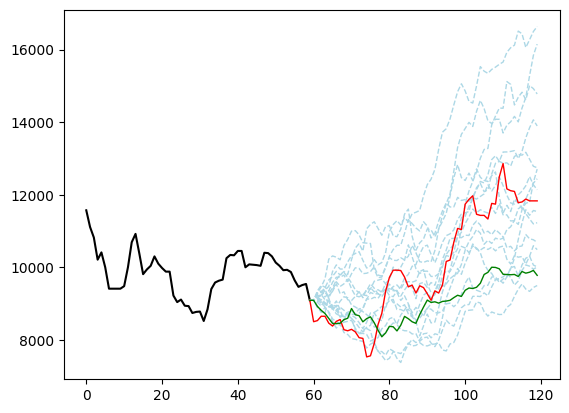

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

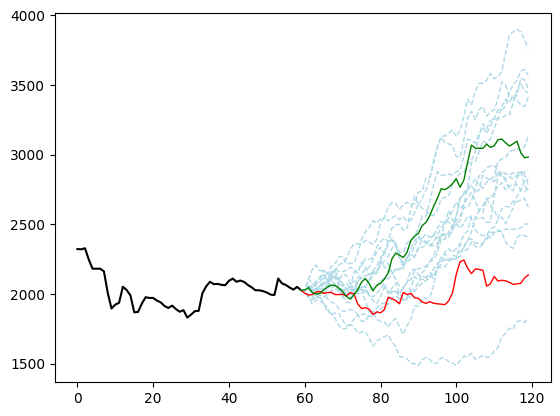

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

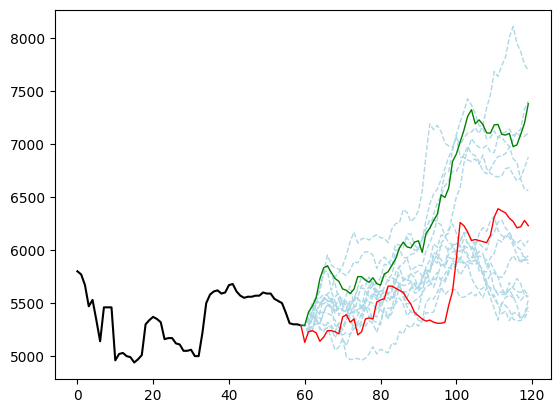

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

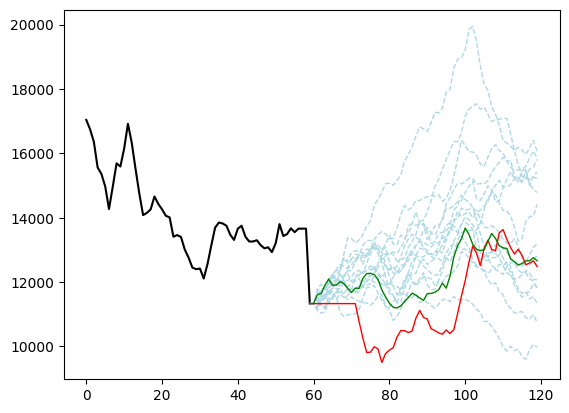

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

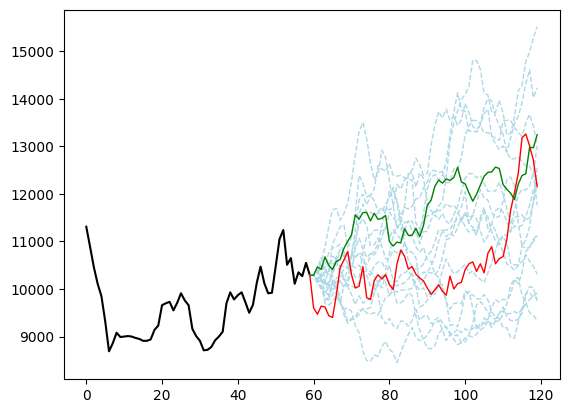

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

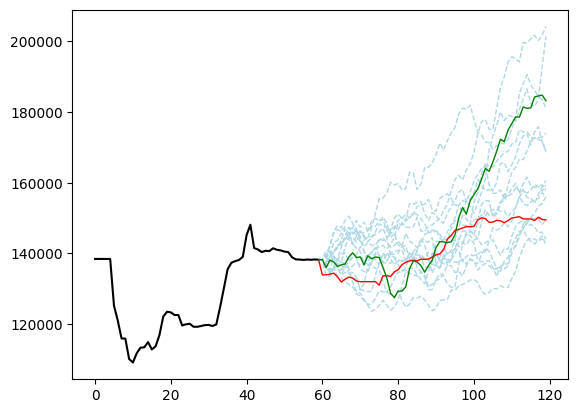

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

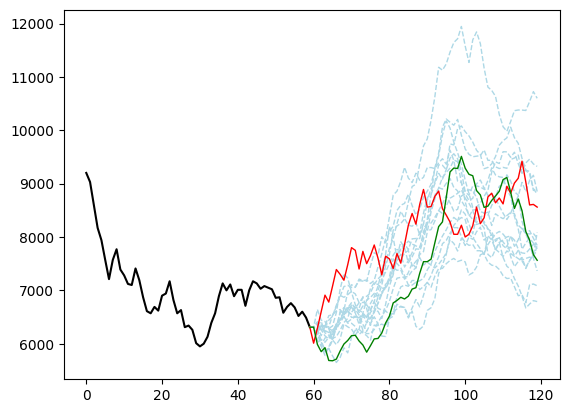

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

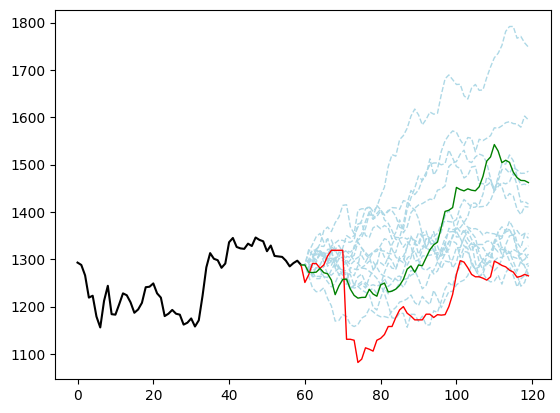

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

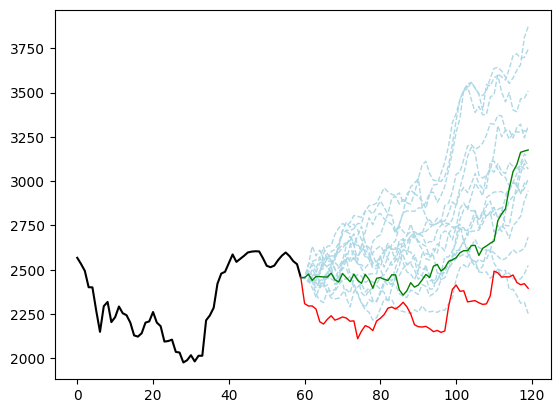

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
for i in range(0,9):
  end = len(new_data[i])
  beg = end - 60
  time = range(len(new_data[i][beg:end]))
  plt.plot(time,new_data[i][beg:end],color="black")
  tim = range(len(new_data[i][beg:end])-1,len(new_data[i][beg:end])+60)
  for j in range(0,15):
    a = np.hstack([new_data[i][end-1],price_prediction2[i][j][:]])
    plt.plot(tim, a, color = 'lightblue', linestyle='dashed', linewidth=1)
  b = np.hstack([new_data[i][end-1],last_60_plt[:,i]])
  plt.plot(tim,b,color = "red", linewidth=1)
  c = np.hstack([new_data[i][end-1],price_prediction_not_boot2[i][:]])
  plt.plot(tim,c,color = "green", linewidth=1)
  plt.savefig(f'stock_g {i+1}.jpg')
  plt.show()
  files.download(f'stock_g {i+1}.jpg')

In [ ]:
def calculate_mean_cov(y_pred):
  mean = np.zeros((15, 9))
  std = np.zeros((15,9))
  for i in range(9):
    for j in range(15):
      mean[j,i] = np.mean(y_pred[i][j])
      std [j,i] = np.std(y_pred[i][j])
  Covariance_Matrix = np.zeros((15,9,9))
  for j in range(15):
    Cov_between = np.array([y_pred[i][j] for i in range(9)])
    CC= Cov_between.reshape(Cov_between.shape[0], Cov_between.shape[2])
    Covariance_Matrix[j,:,:] = np.cov(CC)
  return mean, std, Covariance_Matrix

m2, s2, c2 = calculate_mean_cov(prediction_y_boot2)

In [ ]:
!pip install cvxopt

In [ ]:
!pip install scipy

In [ ]:
import numpy as np
from scipy.optimize import minimize , Bounds
from cvxopt import matrix, solvers
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
from google.colab import files
import os
import io
import xlrd

In [ ]:
Mean = m2
covariance_1 = c2[0,:,:]
covariance_2 = c2[1,:,:]
covariance_3 =c2[2,:,:]
covariance_4 = c2[3,:,:]
covariance_5 = c2[4,:,:]
covariance_6 = c2[5,:,:]
covariance_7 = c2[6,:,:]
covariance_8 = c2[7,:,:]
covariance_9 = c2[8,:,:]
covariance_10 = c2[9,:,:]
covariance_11 = c2[10,:,:]
covariance_12 = c2[11,:,:]
covariance_13 = c2[12,:,:]
covariance_14 = c2[13,:,:]
covariance_15 = c2[14,:,:]

In [ ]:
Covariance =[covariance_1, covariance_2,covariance_3, covariance_4, covariance_5, covariance_6, covariance_7, covariance_8, covariance_9, covariance_10, covariance_11, covariance_12, covariance_13, covariance_14, covariance_15]

In [ ]:
MEAN = []
for i in range (15):
  Mean_row =np.zeros((1,9))
  Mean_row[0,:] = Mean[i,:]
  MEAN.append(Mean_row)

In [ ]:
p_2 = 1/15
#Senario_Optimization
Optimal_value =[]
Optimal_solution =[]
for i in range(15):
  sigma = Covariance[i]
  Q = matrix(sigma, tc='d')
  P = matrix(-MEAN[i], tc='d').T
  G = matrix(-np.eye(9), tc='d')
  h = matrix(np.zeros(9), tc='d')
  A = matrix(np.ones(9), tc='d').T
  b = matrix(1.0)
  Optimal_value_Lambda =[]
  Optimal_solution_Lambda =[]
  for Lambda in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:
    sol = solvers.qp(Lambda*Q,(1-Lambda)*P,G,h,A,b)
    Optimal_value_Lambda.append(sol['primal objective'])
    Optimal_solution_Lambda.append(sol['x'])
  Optimal_value.append(Optimal_value_Lambda)
  Optimal_solution.append(Optimal_solution_Lambda)

     pcost       dcost       gap    pres   dres
 0: -1.9569e-03 -1.0060e+00  1e+00  0e+00  3e+00
 1: -1.9691e-03 -1.5959e-02  1e-02  3e-17  5e-02
 2: -2.7349e-03 -6.0567e-03  3e-03  5e-17  1e-02
 3: -4.3564e-03 -6.8676e-03  3e-03  4e-16  6e-03
 4: -5.9086e-03 -5.9937e-03  9e-05  2e-16  8e-05
 5: -5.9449e-03 -5.9458e-03  9e-07  2e-16  9e-07
 6: -5.9453e-03 -5.9453e-03  9e-09  1e-16  9e-09
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -1.7321e-03 -1.0053e+00  1e+00  3e-16  3e+00
 1: -1.7418e-03 -1.5295e-02  1e-02  5e-17  5e-02
 2: -2.3677e-03 -5.3914e-03  3e-03  7e-17  1e-02
 3: -3.8737e-03 -6.1690e-03  2e-03  8e-16  5e-03
 4: -5.2314e-03 -5.3005e-03  7e-05  2e-16  6e-05
 5: -5.2678e-03 -5.2685e-03  7e-07  1e-16  6e-07
 6: -5.2682e-03 -5.2682e-03  7e-09  2e-21  6e-09
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -1.5087e-03 -1.0046e+00  1e+00  1e-16  3e+00
 1: -1.5161e-03 -1.4631e-02  1e-02  9e-17  4e-02
 2: -2.0132e-03 -4.7265e

In [ ]:
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for j in range (15):
   print("Bootstrap sample",j+1)
   for i in range(9):
    print("lambda =", Lambda_list[i])
    print(Optimal_solution[j][i][:])

Bootstrap sample 1
lambda = 0.1
[ 5.95e-07]
[ 4.10e-08]
[ 9.71e-08]
[ 6.63e-08]
[ 4.51e-08]
[ 2.83e-07]
[ 3.59e-07]
[ 5.62e-08]
[ 1.00e+00]

lambda = 0.2
[ 4.95e-07]
[ 4.10e-08]
[ 1.17e-07]
[ 7.65e-08]
[ 4.67e-08]
[ 3.32e-07]
[ 4.15e-07]
[ 6.28e-08]
[ 1.00e+00]

lambda = 0.3
[ 3.57e-07]
[ 4.04e-08]
[ 1.40e-07]
[ 8.88e-08]
[ 4.82e-08]
[ 3.81e-07]
[ 4.69e-07]
[ 7.07e-08]
[ 1.00e+00]

lambda = 0.4
[ 2.86e-07]
[ 1.29e-07]
[ 2.60e-07]
[ 1.97e-07]
[ 1.41e-07]
[ 5.02e-07]
[ 5.83e-07]
[ 1.73e-07]
[ 1.00e+00]

lambda = 0.5
[ 2.24e-07]
[ 2.07e-07]
[ 3.45e-07]
[ 2.84e-07]
[ 2.20e-07]
[ 5.21e-07]
[ 5.76e-07]
[ 2.59e-07]
[ 1.00e+00]

lambda = 0.6
[ 1.96e-07]
[ 1.79e-07]
[ 2.53e-07]
[ 2.29e-07]
[ 1.86e-07]
[ 2.11e-07]
[ 2.02e-07]
[ 2.15e-07]
[ 1.00e+00]

lambda = 0.7
[ 8.70e-05]
[ 2.17e-07]
[ 2.62e-07]
[ 2.60e-07]
[ 2.15e-07]
[ 5.94e-08]
[ 8.12e-08]
[ 2.52e-07]
[ 1.00e+00]

lambda = 0.8
[ 8.76e-02]
[ 4.84e-08]
[ 5.16e-08]
[ 4.41e-08]
[ 3.44e-08]
[ 4.34e-08]
[ 2.43e-07]
[ 4.53e-08]
[ 9.12e-01]

lambd

In [ ]:
OPT_X =[]
for l in range(15):
  OX =np.zeros((9,9))
  for n in range(9):
    for k in range(9):
      OX[k,n]=Optimal_solution[l][n][k]
  OPT_X.append(OX)

In [ ]:
#Risk
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in range(15):
  print("Bootstrap sample",i+1)
  sigma = Covariance[i]
  for k in range(9):
    print("Lambda =", Lambda_list[k])
    a = np.dot(OPT_X[i][:,k].T, sigma @ OPT_X[i][:,k])
    print(a)

Bootstrap sample 1
Lambda = 0.1
0.0002970233380805853
Lambda = 0.2
0.0002970233005889603
Lambda = 0.3
0.00029702327959636434
Lambda = 0.4
0.0002970228559329832
Lambda = 0.5
0.00029702262138800136
Lambda = 0.6
0.00029702320347449126
Lambda = 0.7
0.0002969797350749143
Lambda = 0.8
0.00025917936190487456
Lambda = 0.9
0.00022616017355673855
Bootstrap sample 2
Lambda = 0.1
0.0002383424714564947
Lambda = 0.2
0.00023830528503144394
Lambda = 0.3
0.00023652999479439833
Lambda = 0.4
0.00020128450603097494
Lambda = 0.5
0.0001677927937860448
Lambda = 0.6
0.00015259849060542303
Lambda = 0.7
0.00014392149708786976
Lambda = 0.8
8.755826502317638e-05
Lambda = 0.9
5.700241430887922e-05
Bootstrap sample 3
Lambda = 0.1
0.0004495035903670781
Lambda = 0.2
0.00044950343585948584
Lambda = 0.3
0.00044950326585083237
Lambda = 0.4
0.00044950309094062067
Lambda = 0.5
0.00044950292367885227
Lambda = 0.6
0.0004495027223259403
Lambda = 0.7
0.00044950273215925164
Lambda = 0.8
0.0004495025254668009
Lambda = 0.9
0.000

In [ ]:
#Retern
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for m in range(15):
  print("Bootstrap sample",m+1)
  for k in range(9):
    print("Lambda =", Lambda_list[k])
    u = np.dot(MEAN[m], OPT_X[m][:,k])
    print(u)

Bootstrap sample 1
Lambda = 0.1
[0.00662235]
Lambda = 0.2
[0.00662235]
Lambda = 0.3
[0.00662235]
Lambda = 0.4
[0.00662235]
Lambda = 0.5
[0.00662234]
Lambda = 0.6
[0.00662235]
Lambda = 0.7
[0.00662229]
Lambda = 0.8
[0.0065589]
Lambda = 0.9
[0.00646738]
Bootstrap sample 2
Lambda = 0.1
[0.00544777]
Lambda = 0.2
[0.00544776]
Lambda = 0.3
[0.00544728]
Lambda = 0.4
[0.00543681]
Lambda = 0.5
[0.00542337]
Lambda = 0.6
[0.00541425]
Lambda = 0.7
[0.00540577]
Lambda = 0.8
[0.00531809]
Lambda = 0.9
[0.00523304]
Bootstrap sample 3
Lambda = 0.1
[0.00698553]
Lambda = 0.2
[0.00698553]
Lambda = 0.3
[0.00698553]
Lambda = 0.4
[0.00698553]
Lambda = 0.5
[0.00698553]
Lambda = 0.6
[0.00698553]
Lambda = 0.7
[0.00698553]
Lambda = 0.8
[0.00698553]
Lambda = 0.9
[0.00644305]
Bootstrap sample 4
Lambda = 0.1
[0.00894512]
Lambda = 0.2
[0.00894512]
Lambda = 0.3
[0.00891562]
Lambda = 0.4
[0.00886127]
Lambda = 0.5
[0.00882874]
Lambda = 0.6
[0.00880431]
Lambda = 0.7
[0.00878292]
Lambda = 0.8
[0.00876698]
Lambda = 0.9
[0

In [ ]:
for m in range(15):
  print("Bootstrap sample",m+1)
  for k in range(9):
    print("Lambda =", Lambda_list[k])
    print(Optimal_value[m][k])

Bootstrap sample 1
Lambda = 0.1
-0.0059452660523609795
Lambda = 0.2
-0.005268179262643195
Lambda = 0.3
-0.004591092569043203
Lambda = 0.4
-0.003914003899172628
Lambda = 0.5
-0.0032369166840696406
Lambda = 0.6
-0.002559832394853327
Lambda = 0.7
-0.0018827427062971772
Lambda = 0.8
-0.0012081088293684804
Lambda = 0.9
-0.0005449664157936675
Bootstrap sample 2
Lambda = 0.1
-0.0048910765915151835
Lambda = 0.2
-0.004334377250302021
Lambda = 0.3
-0.0037776199865848727
Lambda = 0.4
-0.003221831435277452
Lambda = 0.5
-0.0026697384251917295
Lambda = 0.6
-0.002119921155270355
Lambda = 0.7
-0.0015713585154409728
Lambda = 0.8
-0.0010285945981463249
Lambda = 0.9
-0.0004976525952682376
Bootstrap sample 3
Lambda = 0.1
-0.006264506066972634
Lambda = 0.2
-0.0055434765868168845
Lambda = 0.3
-0.004822447251717225
Lambda = 0.4
-0.004101418135716349
Lambda = 0.5
-0.003380389304461818
Lambda = 0.6
-0.002659360719034524
Lambda = 0.7
-0.0019383328270935302
Lambda = 0.8
-0.001217305355254513
Lambda = 0.9
-0.0005

In [ ]:
def objective_function_5(X_0,Lambda,index_Lambda, P):
    X = np.zeros((1,9))
    for j in range(9):
      X[0,j]=X_0[j]
    total_sum = 0
    for i in range(15):
        sigma = Covariance[i]
        mean_matrix = MEAN[i]
        V_s = Optimal_value[i][index_Lambda]
        term1 = np.dot(X, sigma @ X.T)
        term2 = np.dot(mean_matrix, X.T)
        term3 = V_s
        total_sum += p_2*(Lambda*term1 -(1-Lambda)*term2 - term3)**2

    return total_sum

In [ ]:
def constraint_1(s):
    return s[0] + s[1] +s[2] + s[3] + s[4] +s[5] + s[6] + s[7] +s[8]  - 1

In [ ]:
from scipy.optimize import LinearConstraint
linear_constraint = LinearConstraint([[1,1,1,1,1,1,1,1,1]], [1], [1])

In [ ]:
#Problem_5

X_0 = [0,0.3,-1,0.4,0,-0.5,1.1,0.2,0.4]
# constarnt = {'type':'eq', 'fun': constraint_1}
Optimal_solution_5=[]
Optimal_value_5=[]
for i in range(9):
   opt_solution = minimize(objective_function_5,X_0,args=(Lambda_list[i], i, p_2),bounds=Bounds(0,np.inf),constraints=[linear_constraint] , method='trust-constr')
   Optimal_solution_5.append(opt_solution.x)
   Optimal_value_5.append(opt_solution.fun)



print("Optimal solution:", Optimal_solution_5)
print("Optimal value:", Optimal_value_5)

Optimal solution: [array([0.21691809, 0.5523377 , 0.02204503, 0.02148724, 0.02009464,
       0.02269158, 0.04791983, 0.01654432, 0.07996157]), array([0.24592753, 0.58847272, 0.01370324, 0.01309553, 0.01151777,
       0.01446459, 0.03199814, 0.00937867, 0.0714418 ]), array([0.26740022, 0.59600964, 0.01034115, 0.00970758, 0.00909269,
       0.0106248 , 0.02477068, 0.0071758 , 0.06487743]), array([0.21791263, 0.56072778, 0.02066625, 0.02001925, 0.01708403,
       0.02095865, 0.0479273 , 0.01144739, 0.08325673]), array([0.21731735, 0.56775324, 0.01863359, 0.0177641 , 0.01633467,
       0.01905409, 0.0432073 , 0.01256847, 0.0873672 ]), array([0.22495342, 0.49525365, 0.02550798, 0.02597598, 0.02327761,
       0.02826156, 0.0586607 , 0.01891413, 0.09919497]), array([0.26338935, 0.48445151, 0.01967765, 0.01967021, 0.01706428,
       0.02183637, 0.05107802, 0.01463621, 0.10819641]), array([0.16822271, 0.28634027, 0.06335941, 0.06660853, 0.06041977,
       0.07355131, 0.10838455, 0.0481874 , 0.1

In [ ]:
#Risk of Problem_5
Risk_5 =[]
for k in range(9):
  print("Lambda =", Lambda_list[k])
  total_sum = 0
  for i in range(15):
    sigma = Covariance[i]
    total_sum = total_sum+ p_2 *np.dot(Optimal_solution_5[k].T, sigma @ Optimal_solution_5[k])
  print(total_sum)
  Risk_5.append(total_sum)
print(Risk_5)

Lambda = 0.1
0.00012369456201864954
Lambda = 0.2
0.00014180001360571934
Lambda = 0.3
0.00014889775022036326
Lambda = 0.4
0.00012693779632265417
Lambda = 0.5
0.00012938103776599587
Lambda = 0.6
0.00010704411655190646
Lambda = 0.7
0.00011107724551584296
Lambda = 0.8
5.3710261153591366e-05
Lambda = 0.9
3.4036768578484876e-05
[np.float64(0.00012369456201864954), np.float64(0.00014180001360571934), np.float64(0.00014889775022036326), np.float64(0.00012693779632265417), np.float64(0.00012938103776599587), np.float64(0.00010704411655190646), np.float64(0.00011107724551584296), np.float64(5.3710261153591366e-05), np.float64(3.4036768578484876e-05)]


In [ ]:
#Retern of Problem_5
Retern_5 =[]
for k in range(9):
  print("Lambda =", Lambda_list[k])
  total_sum = 0
  for i in range(15):
    total_sum = total_sum+ p_2 *np.dot(MEAN[i], Optimal_solution_5[k])
  print(total_sum)
  Retern_5.append(total_sum)

print(Retern_5)

Lambda = 0.1
[0.00530454]
Lambda = 0.2
[0.00547474]
Lambda = 0.3
[0.00553498]
Lambda = 0.4
[0.00534898]
Lambda = 0.5
[0.00536807]
Lambda = 0.6
[0.00516413]
Lambda = 0.7
[0.0052253]
Lambda = 0.8
[0.0043639]
Lambda = 0.9
[0.00346947]
[array([0.00530454]), array([0.00547474]), array([0.00553498]), array([0.00534898]), array([0.00536807]), array([0.00516413]), array([0.0052253]), array([0.0043639]), array([0.00346947])]


In [ ]:
# Sharpe Ratio
for k in range (9): # for  lambda
  Sh_R = Retern_5[k]/ Risk_5[k]
  print("Lambda =", Lambda_list[k])
  print(Sh_R)

Lambda = 0.1
[42.884145]
Lambda = 0.2
[38.60887943]
Lambda = 0.3
[37.17304297]
Lambda = 0.4
[42.13855893]
Lambda = 0.5
[41.49038429]
Lambda = 0.6
[48.24304918]
Lambda = 0.7
[47.04199708]
Lambda = 0.8
[81.24885696]
Lambda = 0.9
[101.93307607]


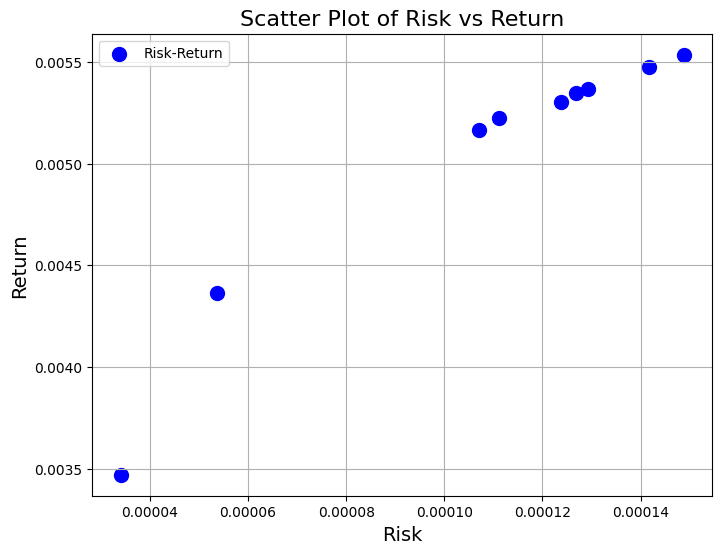

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(Risk_5, Retern_5, color='blue', label='Risk-Return', s=100)
plt.xlabel('Risk', fontsize=14)
plt.ylabel('Return', fontsize=14)
plt.title('Scatter Plot of Risk vs Return', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
pred_nb = np.array(prediction_y_not_boot2).reshape((9,60))
mean =np.mean(pred_nb, axis=1)
mean.shape

(9,)

In [ ]:
covariance_Matrix =np.cov(pred_nb, rowvar=True)
covariance_Matrix.shape

(9, 9)

In [ ]:
#Mean_Variance_Optimization

sigma = covariance_Matrix
P = matrix(sigma, tc='d')
q = - matrix(mean.astype(np.double), tc='d')
G = matrix(-np.eye(9), tc='d')
h = matrix(np.zeros(9), tc='d')
A = matrix(np.ones(9), tc='d').T
b = matrix(1.0)
Optimal_value_Lambda =[]
Optimal_solution_Lambda =[]
for Lambda in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:
  sol = solvers.qp(Lambda*P,(1-Lambda)*q,G,h,A,b)
  Optimal_value_Lambda.append(sol['primal objective'])
  Optimal_solution_Lambda.append(sol['x'])

     pcost       dcost       gap    pres   dres
 0: -3.5460e-03 -1.0060e+00  1e+00  0e+00  3e+00
 1: -3.5510e-03 -1.5952e-02  1e-02  2e-16  4e-02
 2: -3.8815e-03 -6.0512e-03  2e-03  1e-16  7e-03
 3: -5.1442e-03 -6.8319e-03  2e-03  7e-16  4e-03
 4: -5.8820e-03 -5.9518e-03  7e-05  4e-16  1e-04
 5: -5.9423e-03 -5.9430e-03  7e-07  2e-16  1e-06
 6: -5.9429e-03 -5.9429e-03  7e-09  2e-16  1e-08
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.1475e-03 -1.0053e+00  1e+00  2e-16  3e+00
 1: -3.1514e-03 -1.5286e-02  1e-02  6e-17  4e-02
 2: -3.4224e-03 -5.3845e-03  2e-03  5e-17  6e-03
 3: -4.5773e-03 -6.1024e-03  2e-03  2e-16  3e-03
 4: -5.2086e-03 -5.2760e-03  7e-05  3e-16  1e-04
 5: -5.2670e-03 -5.2677e-03  7e-07  2e-16  1e-06
 6: -5.2676e-03 -5.2676e-03  7e-09  1e-16  1e-08
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -2.7495e-03 -1.0046e+00  1e+00  2e-16  3e+00
 1: -2.7525e-03 -1.4620e-02  1e-02  4e-17  4e-02
 2: -2.9682e-03 -4.7179e

In [ ]:
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in range(9):
  print("lambda =", Lambda_list[i])
  print(Optimal_value_Lambda[i])

lambda = 0.1
-0.005942924259209278
lambda = 0.2
-0.005267634945875788
lambda = 0.3
-0.004592345890616983
lambda = 0.4
-0.003917057279814221
lambda = 0.5
-0.003241769412572422
lambda = 0.6
-0.0025664812250545607
lambda = 0.7
-0.0018911914351217806
lambda = 0.8
-0.001216515922023808
lambda = 0.9
-0.0005655806103369572


In [ ]:
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
X_OPT_No =[]
for i in range(9):
  print("lambda =", Lambda_list[i])
  X = np.zeros(9)
  for j in range(9):
    X[j] = Optimal_solution_Lambda[i][j]
  print(X)
  X_OPT_No.append(X)

lambda = 0.1
[1.62477133e-07 9.99997401e-01 1.30542393e-07 2.03058269e-07
 4.57207596e-07 5.65603689e-07 3.46114847e-07 2.13928383e-07
 5.19676527e-07]
lambda = 0.2
[1.88331373e-07 9.99997201e-01 1.25826725e-07 2.34043565e-07
 4.98240400e-07 5.76592552e-07 3.82113802e-07 2.45809153e-07
 5.47631247e-07]
lambda = 0.3
[2.13269710e-07 9.99997082e-01 1.16322227e-07 2.63588995e-07
 5.27114995e-07 5.57972032e-07 4.09779752e-07 2.75874410e-07
 5.54370691e-07]
lambda = 0.4
[2.26244453e-07 9.99997196e-01 1.01622554e-07 2.78607659e-07
 5.17586441e-07 4.73423583e-07 4.08045337e-07 2.90384886e-07
 5.07764091e-07]
lambda = 0.5
[1.99266284e-07 9.99997929e-01 8.51479890e-08 2.45464688e-07
 4.01818452e-07 2.33493007e-07 3.24253380e-07 2.54043209e-07
 3.27575611e-07]
lambda = 0.6
[1.42403679e-07 9.99997836e-01 1.05032875e-06 1.75675736e-07
 2.55863528e-07 4.41780682e-08 1.89144336e-07 1.78657719e-07
 1.27333031e-07]
lambda = 0.7
[6.43781900e-08 9.99984391e-01 1.48494323e-05 8.20405980e-08
 2.27984387e-0

In [ ]:
#Risk
Risk_No =[]
sigma = covariance_Matrix
for i in range(9):
   print("lambda =", Lambda_list[i])
   print(np.dot(X_OPT_No[i].T, sigma @ X_OPT_No[i]))
   Risk_No.append(np.dot(X_OPT_No[i].T, sigma @ X_OPT_No[i]))

print(Risk_No)

lambda = 0.1
0.0002693492261901747
lambda = 0.2
0.0002693491308180366
lambda = 0.3
0.00026934907161819125
lambda = 0.4
0.0002693491196251286
lambda = 0.5
0.0002693494521164995
lambda = 0.6
0.00026934938604959957
lambda = 0.7
0.0002693428715536365
lambda = 0.8
0.00023968563245478522
lambda = 0.9
0.00013980962325012684
[np.float64(0.0002693492261901747), np.float64(0.0002693491308180366), np.float64(0.00026934907161819125), np.float64(0.0002693491196251286), np.float64(0.0002693494521164995), np.float64(0.00026934938604959957), np.float64(0.0002693428715536365), np.float64(0.00023968563245478522), np.float64(0.00013980962325012684)]


In [ ]:
#Retern
Retern_No =[]
for i in range(9):
  print("lambda =", Lambda_list[i])
  print(np.dot(mean, X_OPT_No[i]))
  Retern_No.append(np.dot(mean, X_OPT_No[i]))

print(Retern_No)

lambda = 0.1
0.006618213022798651
lambda = 0.2
0.0066182123236969885
lambda = 0.3
0.00661821178765673
lambda = 0.4
0.006618211839565411
lambda = 0.5
0.006618213551203092
lambda = 0.6
0.006618215102173601
lambda = 0.7
0.006618204800551844
lambda = 0.8
0.006561950875028612
lambda = 0.9
0.006284949407995145
[np.float64(0.006618213022798651), np.float64(0.0066182123236969885), np.float64(0.00661821178765673), np.float64(0.006618211839565411), np.float64(0.006618213551203092), np.float64(0.006618215102173601), np.float64(0.006618204800551844), np.float64(0.006561950875028612), np.float64(0.006284949407995145)]


In [ ]:
# Sharpe Ratio
for k in range (9): # for  lambda
  Sh_R2 = Retern_No[k]/ Risk_No[k]
  print("Lambda =", Lambda_list[k])
  print(Sh_R2)

Lambda = 0.1
24.57112320837278
Lambda = 0.2
24.571129313084864
Lambda = 0.3
24.57113272340587
Lambda = 0.4
24.571128536734868
Lambda = 0.5
24.5711045602594
Lambda = 0.6
24.571116345351108
Lambda = 0.7
24.571672390571905
Lambda = 0.8
27.377322569664127
Lambda = 0.9
44.953625236161585


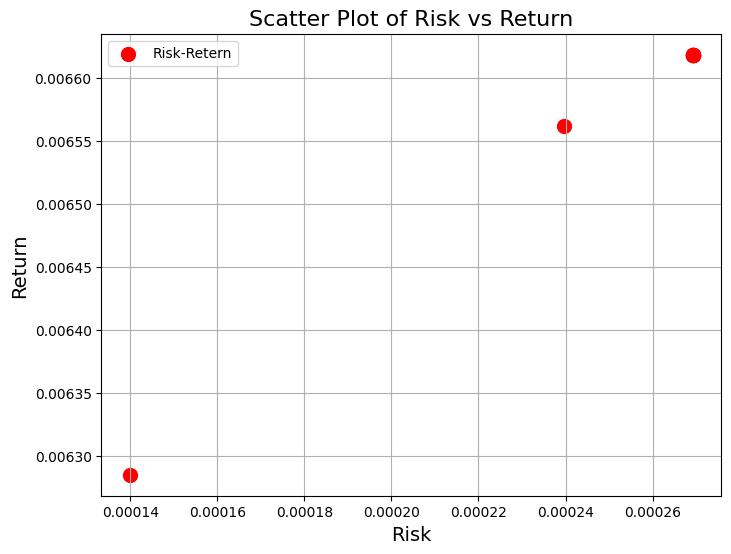

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(Risk_No, Retern_No, color = 'red', label= 'Risk-Retern', s =100)
plt.xlabel('Risk', fontsize=14)
plt.ylabel('Return', fontsize=14)
plt.title('Scatter Plot of Risk vs Return', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
meanr =np.mean(last_60_new, axis=1)
meanr.shape

(9,)

In [ ]:
covariance_Matrixr =np.cov(last_60_new, rowvar=True)
covariance_Matrixr.shape

(9, 9)

In [ ]:
#Mean_Variance_Optimization

sigmar = covariance_Matrixr
P = matrix(sigmar, tc='d')
q = -matrix(meanr.astype(np.double), tc='d')
G = matrix(-np.eye(9), tc='d')
h = matrix(np.zeros(9), tc='d')
A = matrix(np.ones(9), tc='d').T
b = matrix(1.0)
Optimal_value_Lambda =[]
Optimal_solution_Lambda =[]
for Lambda in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:
  sol = solvers.qp(Lambda*P,(1-Lambda)*q,G,h,A,b)
  Optimal_value_Lambda.append(sol['primal objective'])
  Optimal_solution_Lambda.append(sol['x'])

     pcost       dcost       gap    pres   dres
 0: -2.0601e-03 -1.0050e+00  1e+00  2e-16  3e+00
 1: -2.0659e-03 -1.5005e-02  1e-02  5e-17  4e-02
 2: -2.4690e-03 -5.1009e-03  3e-03  2e-16  8e-03
 3: -3.9021e-03 -5.9102e-03  2e-03  9e-16  4e-03
 4: -4.9134e-03 -4.9760e-03  6e-05  2e-16  8e-05
 5: -4.9661e-03 -4.9667e-03  6e-07  6e-19  8e-07
 6: -4.9666e-03 -4.9666e-03  6e-09  1e-20  8e-09
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -1.8182e-03 -1.0044e+00  1e+00  2e-16  3e+00
 1: -1.8228e-03 -1.4437e-02  1e-02  1e-16  4e-02
 2: -2.1498e-03 -4.5301e-03  2e-03  8e-17  8e-03
 3: -3.6039e-03 -5.3527e-03  2e-03  2e-17  4e-03
 4: -4.2941e-03 -4.3706e-03  8e-05  9e-18  1e-04
 5: -4.3601e-03 -4.3608e-03  8e-07  8e-19  1e-06
 6: -4.3607e-03 -4.3607e-03  8e-09  3e-16  1e-08
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -1.5769e-03 -1.0039e+00  1e+00  2e-16  3e+00
 1: -1.5804e-03 -1.3869e-02  1e-02  7e-17  4e-02
 2: -1.8379e-03 -3.9600e

In [ ]:
Lambda_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
X_OPT_r =[]
for i in range(9):
  print("lambda =", Lambda_list[i])
  X = np.zeros(9)
  for j in range(9):
    X[j] = Optimal_solution_Lambda[i][j]
  print(X)
  X_OPT_r.append(X)

lambda = 0.1
[2.52191653e-07 1.68552578e-07 4.00099103e-07 2.43718748e-07
 4.69001307e-07 1.88672861e-07 9.99998059e-01 1.12318850e-07
 1.06177055e-07]
lambda = 0.2
[1.90264165e-07 2.79292085e-07 4.80184848e-07 3.53882236e-07
 5.14882743e-07 2.98803115e-07 9.99997468e-01 2.11061170e-07
 2.03762700e-07]
lambda = 0.3
[1.83749862e-07 2.35620587e-07 2.75135728e-07 2.68754867e-07
 2.34375435e-07 2.40600142e-07 9.99998193e-01 1.86606038e-07
 1.82388826e-07]
lambda = 0.4
[1.46016733e-04 2.88963427e-07 1.94725219e-07 2.97120851e-07
 5.94737490e-08 2.70926049e-07 9.99852412e-01 2.30207983e-07
 2.29908086e-07]
lambda = 0.5
[1.37880966e-01 1.47858749e-06 2.77081923e-06 1.86401804e-06
 3.12464881e-06 1.62442267e-06 8.62105942e-01 1.13575766e-06
 1.09449548e-06]
lambda = 0.6
[2.65171340e-01 3.49529479e-06 6.50896697e-06 4.37724309e-06
 7.17025760e-06 3.85285452e-06 7.34798084e-01 2.63268976e-06
 2.53873286e-06]
lambda = 0.7
[3.56116049e-01 1.62623267e-06 3.43657569e-06 2.05045674e-06
 3.96075028e-0

In [ ]:
#Risk
Risk_r =[]
sigmar = covariance_Matrixr
for i in range(9):
   print("lambda =", Lambda_list[i])
   print(np.dot(X_OPT_r[i].T, sigmar @ X_OPT_r[i]))
   Risk_r.append(np.dot(X_OPT_r[i].T, sigmar @ X_OPT_r[i]))

print(Risk_r)

lambda = 0.1
0.0009729716216764105
lambda = 0.2
0.0009729706126233486
lambda = 0.3
0.0009729717989082616
lambda = 0.4
0.0009726804619655211
lambda = 0.5
0.0007339713691429258
lambda = 0.6
0.0005782004123085923
lambda = 0.7
0.0005050848470667473
lambda = 0.8
0.0004710971251508283
lambda = 0.9
0.00042740656552711404
[np.float64(0.0009729716216764105), np.float64(0.0009729706126233486), np.float64(0.0009729717989082616), np.float64(0.0009726804619655211), np.float64(0.0007339713691429258), np.float64(0.0005782004123085923), np.float64(0.0005050848470667473), np.float64(0.0004710971251508283), np.float64(0.00042740656552711404)]


In [ ]:
#Retern
Retern_r =[]
for i in range(9):
  print("lambda =", Lambda_list[i])
  print(np.dot(meanr, X_OPT_r[i]))
  Retern_r.append(np.dot(meanr, X_OPT_r[i]))

print(Retern_r)

lambda = 0.1
0.005572518743175994
lambda = 0.2
0.005572515965781392
lambda = 0.3
0.0055725182212287335
lambda = 0.4
0.005572410793989099
lambda = 0.5
0.005471244344151166
lambda = 0.6
0.005377723167154718
lambda = 0.7
0.00531100970222982
lambda = 0.8
0.005260940717031165
lambda = 0.9
0.005092612115666115
[np.float64(0.005572518743175994), np.float64(0.005572515965781392), np.float64(0.0055725182212287335), np.float64(0.005572410793989099), np.float64(0.005471244344151166), np.float64(0.005377723167154718), np.float64(0.00531100970222982), np.float64(0.005260940717031165), np.float64(0.005092612115666115)]


In [ ]:
# Sharpe Ratio
for k in range (9): # for  lambda
  Sh_R3 = Retern_r[k]/ Risk_r[k]
  print("Lambda =", Lambda_list[k])
  print(Sh_R3)

Lambda = 0.1
5.72731888477349
Lambda = 0.2
5.727321969937642
Lambda = 0.3
5.727317305066258
Lambda = 0.4
5.728922304791423
Lambda = 0.5
7.454302135163741
Lambda = 0.6
9.300794417774584
Lambda = 0.7
10.515084214213154
Lambda = 0.8
11.167422673926955
Lambda = 0.9
11.915147137212257


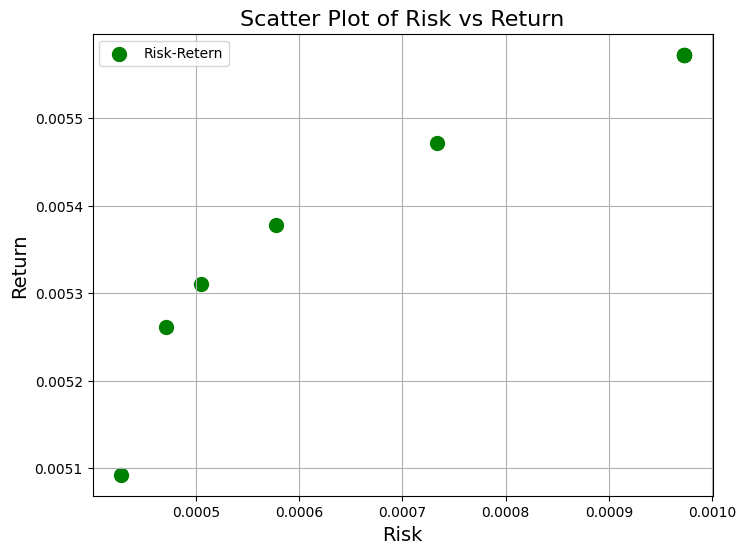

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(Risk_r, Retern_r, color = 'green', label= 'Risk-Retern', s =100)
plt.xlabel('Risk', fontsize=14)
plt.ylabel('Return', fontsize=14)
plt.title('Scatter Plot of Risk vs Return', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
[sum(abs(Optimal_solution_5[i]-X_OPT_r[i])) for i in range(9)]

[np.float64(1.9041564580796542),
 np.float64(1.9359986543866226),
 np.float64(1.9504550195048023),
 np.float64(1.9038502311905066),
 np.float64(1.6377972912331065),
 np.float64(1.432710603751563),
 np.float64(1.3710349117995433),
 np.float64(1.446763305628587),
 np.float64(1.463206333983914)]

In [ ]:
[sum(abs(X_OPT_No[i]-X_OPT_r[i])) for i in range(9)]

[np.float64(1.999996249756837),
 np.float64(1.9999951570501282),
 np.float64(1.99999589393627),
 np.float64(1.999995812001406),
 np.float64(1.9999929006997772),
 np.float64(1.999988682240733),
 np.float64(1.9999883546883135),
 np.float64(1.9999828299416165),
 np.float64(1.9056210762484007)]